In [4]:
# Önce gerekli kütüphaneleri kuralım
import subprocess
subprocess.run(["pip", "install", "mne", "matplotlib", "numpy", "scipy", "seaborn"], 
               capture_output=True)
print("✅ Kurulum tamam!")

✅ Kurulum tamam!


In [5]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os

mne.set_log_level('WARNING')  # Gereksiz logları kapat
print(f"✅ MNE version: {mne.__version__}")
print(f"✅ NumPy version: {np.__version__}")

✅ MNE version: 1.11.0
✅ NumPy version: 1.26.4


In [12]:
# Dosya yolunu ayarla
data_path = r"C:\Users\berke\eeg_analysis\data"
file_path = os.path.join(data_path, "S001R01.edf")  # Dinlenme (gözler açık)

# EDF dosyasını yükle
raw = mne.io.read_raw_edf(file_path, preload=True)

# Temel bilgileri göster
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [13]:
# Kanal sayısı, süre, sampling rate
n_channels = len(raw.ch_names)
duration = raw.times[-1]
sfreq = raw.info['sfreq']

print(f"📡 Kanal sayısı   : {n_channels}")
print(f"⏱️  Kayıt süresi   : {duration:.1f} saniye")
print(f"🔁 Sampling rate  : {sfreq} Hz")
print(f"\n📋 Kanallar:")
for i, ch in enumerate(raw.ch_names):
    print(f"   {i+1:2d}. {ch}")

📡 Kanal sayısı   : 64
⏱️  Kayıt süresi   : 61.0 saniye
🔁 Sampling rate  : 160.0 Hz

📋 Kanallar:
    1. Fc5.
    2. Fc3.
    3. Fc1.
    4. Fcz.
    5. Fc2.
    6. Fc4.
    7. Fc6.
    8. C5..
    9. C3..
   10. C1..
   11. Cz..
   12. C2..
   13. C4..
   14. C6..
   15. Cp5.
   16. Cp3.
   17. Cp1.
   18. Cpz.
   19. Cp2.
   20. Cp4.
   21. Cp6.
   22. Fp1.
   23. Fpz.
   24. Fp2.
   25. Af7.
   26. Af3.
   27. Afz.
   28. Af4.
   29. Af8.
   30. F7..
   31. F5..
   32. F3..
   33. F1..
   34. Fz..
   35. F2..
   36. F4..
   37. F6..
   38. F8..
   39. Ft7.
   40. Ft8.
   41. T7..
   42. T8..
   43. T9..
   44. T10.
   45. Tp7.
   46. Tp8.
   47. P7..
   48. P5..
   49. P3..
   50. P1..
   51. Pz..
   52. P2..
   53. P4..
   54. P6..
   55. P8..
   56. Po7.
   57. Po3.
   58. Poz.
   59. Po4.
   60. Po8.
   61. O1..
   62. Oz..
   63. O2..
   64. Iz..


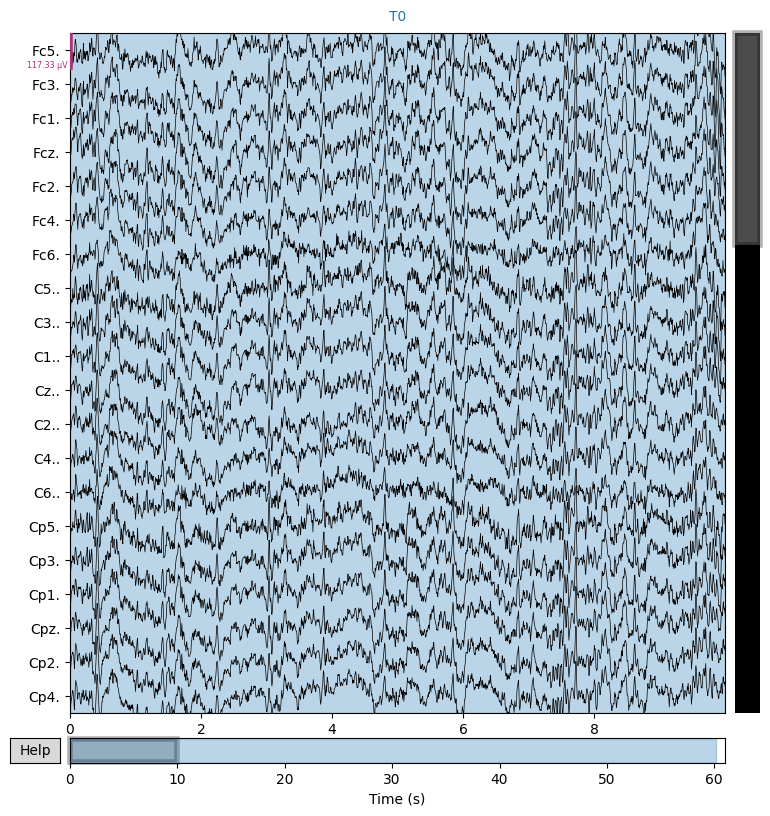

In [14]:
# İlk 10 saniyeyi çiz
raw.plot(duration=10, 
         n_channels=20, 
         scalings='auto',
         title='Ham EEG Sinyali - S001R01 (Dinlenme)',
         show=True)
plt.show()

In [15]:
# Kanal isimlerini standart 10-20 sistemine göre düzenle
raw.rename_channels(lambda x: x.strip('.'))  # "Fc5." → "Fc5"

# Standart elektrot pozisyonlarını ata
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, on_missing='ignore')

print("✅ Elektrot pozisyonları atandı!")
print(f"İlk 5 kanal: {raw.ch_names[:5]}")

✅ Elektrot pozisyonları atandı!
İlk 5 kanal: ['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2']


In [16]:
# 1-40 Hz bant geçiren filtre uygula
raw_filtered = raw.copy().filter(
    l_freq=1.0,    # Alt kesim: 1 Hz (DC drift temizle)
    h_freq=40.0,   # Üst kesim: 40 Hz (kas artefaktı temizle)
    method='fir',
    fir_design='firwin'
)

print("✅ Filtre uygulandı: 1-40 Hz")

✅ Filtre uygulandı: 1-40 Hz


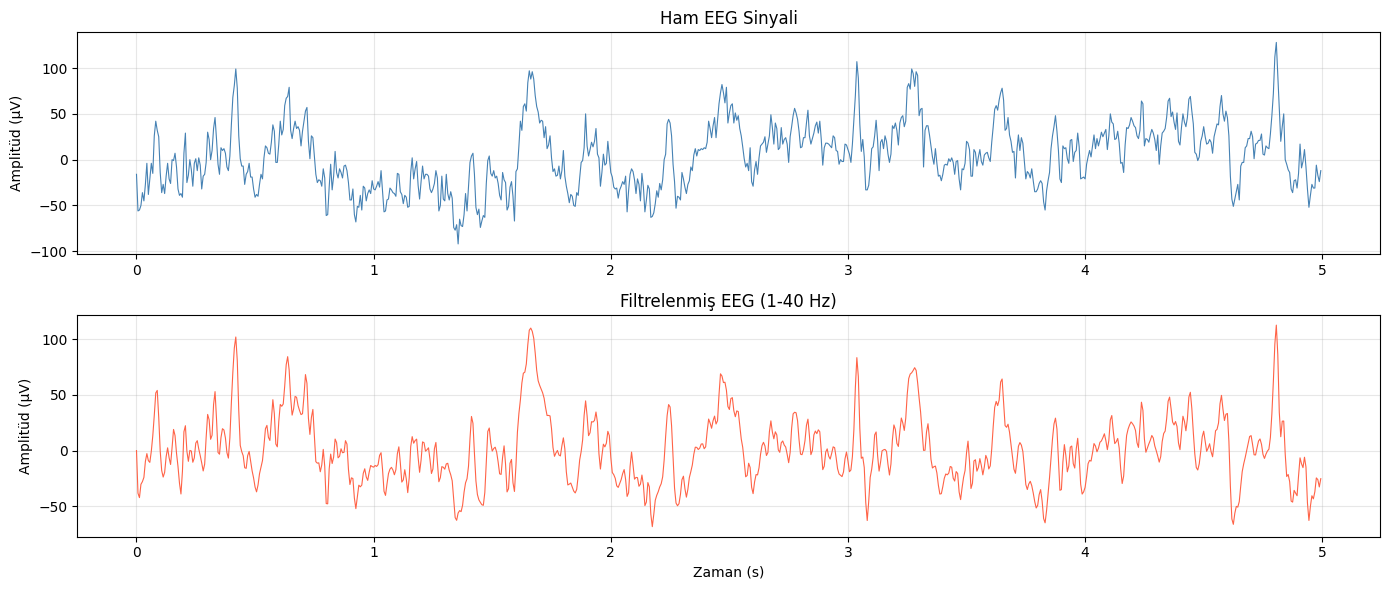

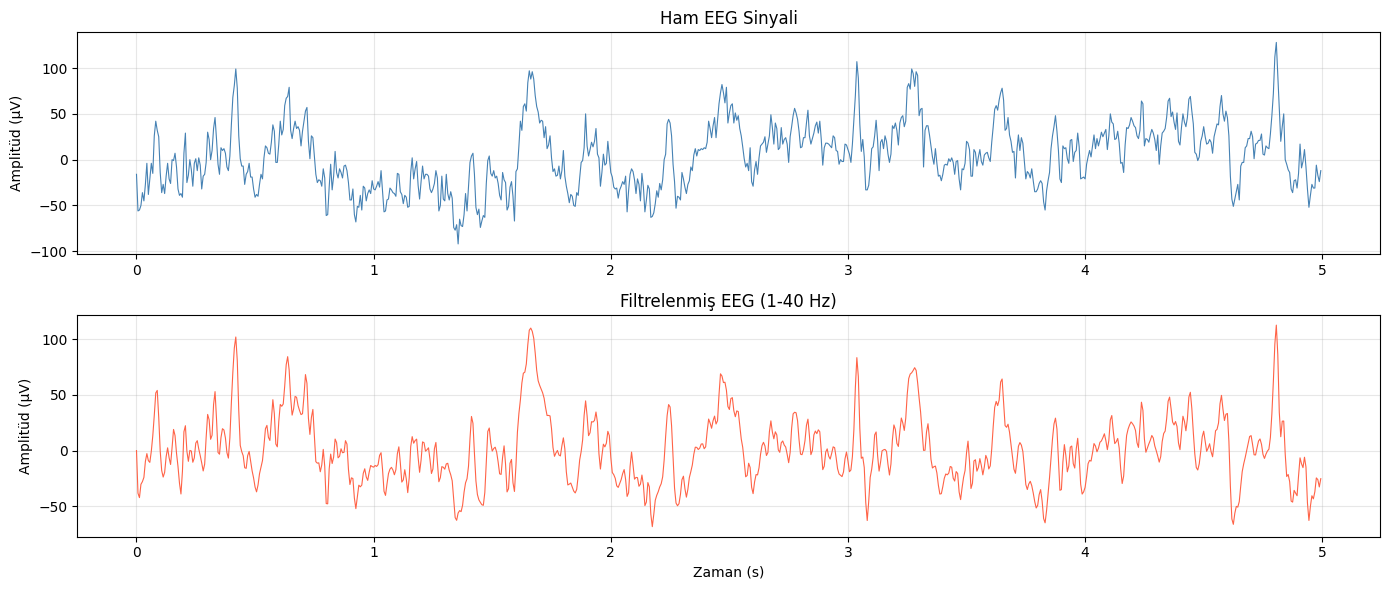

✅ Grafik kaydedildi!


In [18]:
%matplotlib inline
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Ham sinyal (ilk kanal, ilk 5 saniye)
times = raw.times[:800]  # 5 saniye @ 160Hz
raw_data = raw.get_data(picks=[0])[:, :800]
filtered_data = raw_filtered.get_data(picks=[0])[:, :800]

axes[0].plot(times, raw_data[0] * 1e6, color='steelblue', linewidth=0.8)
axes[0].set_title('Ham EEG Sinyali', fontsize=12)
axes[0].set_ylabel('Amplitüd (μV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, filtered_data[0] * 1e6, color='tomato', linewidth=0.8)
axes[1].set_title('Filtrelenmiş EEG (1-40 Hz)', fontsize=12)
axes[1].set_ylabel('Amplitüd (μV)')
axes[1].set_xlabel('Zaman (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs(r"C:\eeg_analysis\outputs", exist_ok=True)
plt.savefig(r"C:\eeg_analysis\outputs\01_filtering.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

In [19]:
# EEG frekans bantları
bands = {
    'Delta': (0.5, 4),    # Derin uyku
    'Theta': (4, 8),      # Uyuklama, meditasyon
    'Alpha': (8, 13),     # Dinlenme, gözler kapalı
    'Beta':  (13, 30),    # Aktif düşünme, konsantrasyon
    'Gamma': (30, 40)     # Yüksek bilişsel aktivite
}

print("✅ Frekans bantları tanımlandı:")
for band, (low, high) in bands.items():
    print(f"   {band:6s}: {low}-{high} Hz")

✅ Frekans bantları tanımlandı:
   Delta : 0.5-4 Hz
   Theta : 4-8 Hz
   Alpha : 8-13 Hz
   Beta  : 13-30 Hz
   Gamma : 30-40 Hz


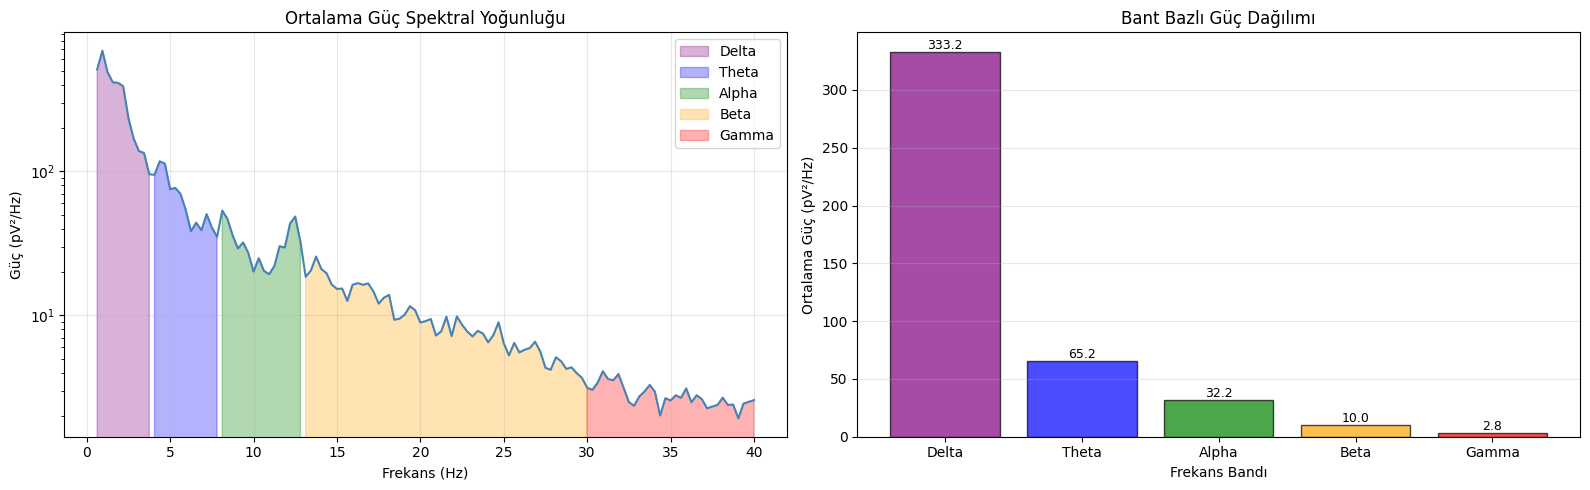

✅ PSD analizi tamamlandı!


In [20]:
%matplotlib inline
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PSD hesapla
spectrum = raw_filtered.compute_psd(method='welch', fmin=0.5, fmax=40, n_fft=512)
freqs = spectrum.freqs
psds = spectrum.get_data()  # shape: (n_channels, n_freqs)

# Sol: Tüm kanalların ortalama PSD
mean_psd = psds.mean(axis=0) * 1e12  # V²/Hz → pV²/Hz
axes[0].semilogy(freqs, mean_psd, color='steelblue', linewidth=1.5)

# Bant renklerini vurgula
colors = ['purple', 'blue', 'green', 'orange', 'red']
for (band, (low, high)), color in zip(bands.items(), colors):
    mask = (freqs >= low) & (freqs <= high)
    axes[0].fill_between(freqs[mask], mean_psd[mask], 
                          alpha=0.3, color=color, label=band)

axes[0].set_xlabel('Frekans (Hz)')
axes[0].set_ylabel('Güç (pV²/Hz)')
axes[0].set_title('Ortalama Güç Spektral Yoğunluğu')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sağ: Her bant için ortalama güç (bar chart)
band_powers = []
band_names = []
for band, (low, high) in bands.items():
    mask = (freqs >= low) & (freqs <= high)
    power = psds[:, mask].mean()
    band_powers.append(power * 1e12)
    band_names.append(band)

bars = axes[1].bar(band_names, band_powers, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Frekans Bandı')
axes[1].set_ylabel('Ortalama Güç (pV²/Hz)')
axes[1].set_title('Bant Bazlı Güç Dağılımı')
axes[1].grid(True, alpha=0.3, axis='y')

# Bar üzerine değer yaz
for bar, val in zip(bars, band_powers):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
os.makedirs(r"C:\eeg_analysis\outputs", exist_ok=True)
plt.savefig(r"C:\eeg_analysis\outputs\02_psd_analysis.png", dpi=150)
plt.show()
print("✅ PSD analizi tamamlandı!")

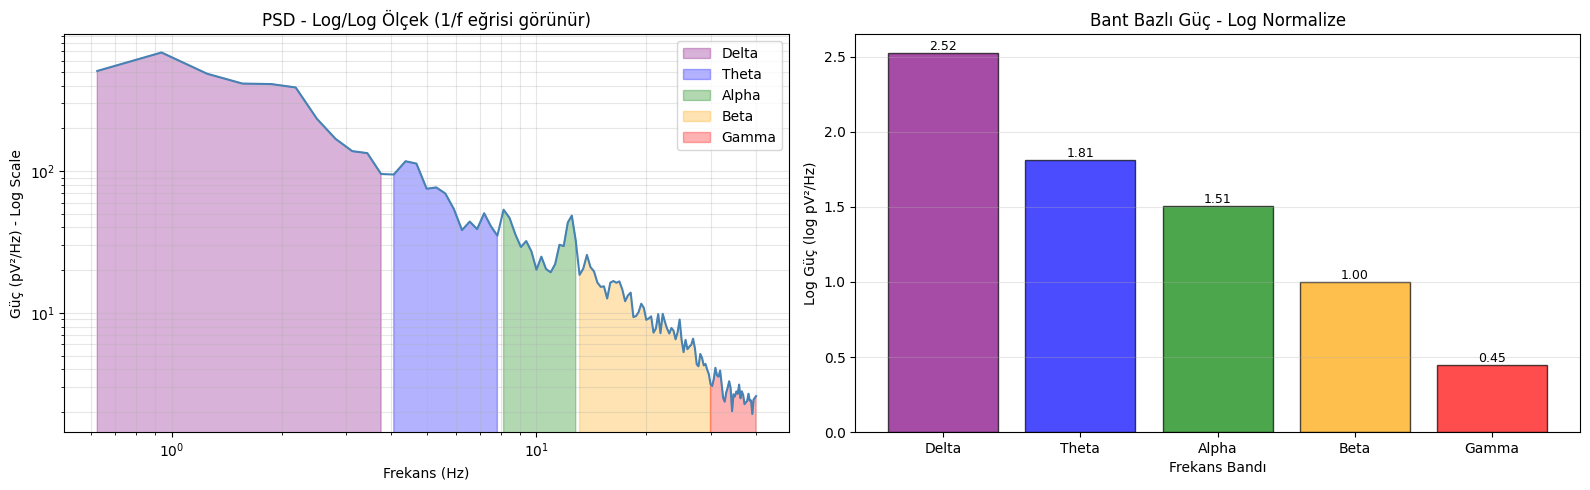

✅ Normalize PSD tamamlandı!


In [21]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

spectrum = raw_filtered.compute_psd(method='welch', fmin=0.5, fmax=40, n_fft=512)
freqs = spectrum.freqs
psds = spectrum.get_data()

# Sol: Log-log scale PSD
mean_psd = psds.mean(axis=0) * 1e12
colors_list = ['purple', 'blue', 'green', 'orange', 'red']

axes[0].loglog(freqs, mean_psd, color='steelblue', linewidth=1.5)
for (band, (low, high)), color in zip(bands.items(), colors_list):
    mask = (freqs >= low) & (freqs <= high)
    axes[0].fill_between(freqs[mask], mean_psd[mask],
                          alpha=0.3, color=color, label=band)

axes[0].set_xlabel('Frekans (Hz)')
axes[0].set_ylabel('Güç (pV²/Hz) - Log Scale')
axes[0].set_title('PSD - Log/Log Ölçek (1/f eğrisi görünür)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, which='both')

# Sağ: Normalize edilmiş güç (Delta'yı ezip diğerlerini göster)
band_powers = []
band_names = []
for band, (low, high) in bands.items():
    mask = (freqs >= low) & (freqs <= high)
    power = np.log10(psds[:, mask].mean() * 1e12)  # dB benzeri
    band_powers.append(power)
    band_names.append(band)

bars = axes[1].bar(band_names, band_powers, color=colors_list, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Frekans Bandı')
axes[1].set_ylabel('Log Güç (log pV²/Hz)')
axes[1].set_title('Bant Bazlı Güç - Log Normalize')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, band_powers):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\eeg_analysis\outputs\02b_psd_normalized.png", dpi=150)
plt.show()
print("✅ Normalize PSD tamamlandı!")

In [23]:
# Montage'ı sıfırla ve düzgün ata
raw_filtered.set_montage(None)  # Önce temizle

# Kanal isimlerini kontrol et
print(raw_filtered.ch_names[:10])

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1']


In [25]:
montage = mne.channels.make_standard_montage('biosemi64')
raw_filtered.set_montage(montage, on_missing='ignore', match_case=False)

print("✅ Montage atandı!")
print(f"Kanal pozisyonu örnek: {raw_filtered.info['chs'][0]['loc'][:3]}")

✅ Montage atandı!
Kanal pozisyonu örnek: [-0.08434934  0.03237868  0.06950535]


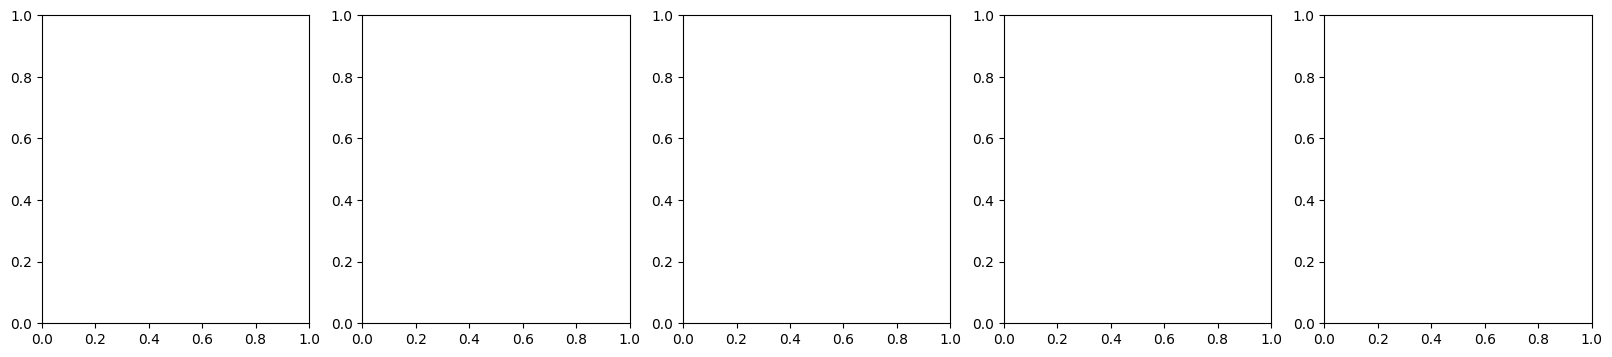

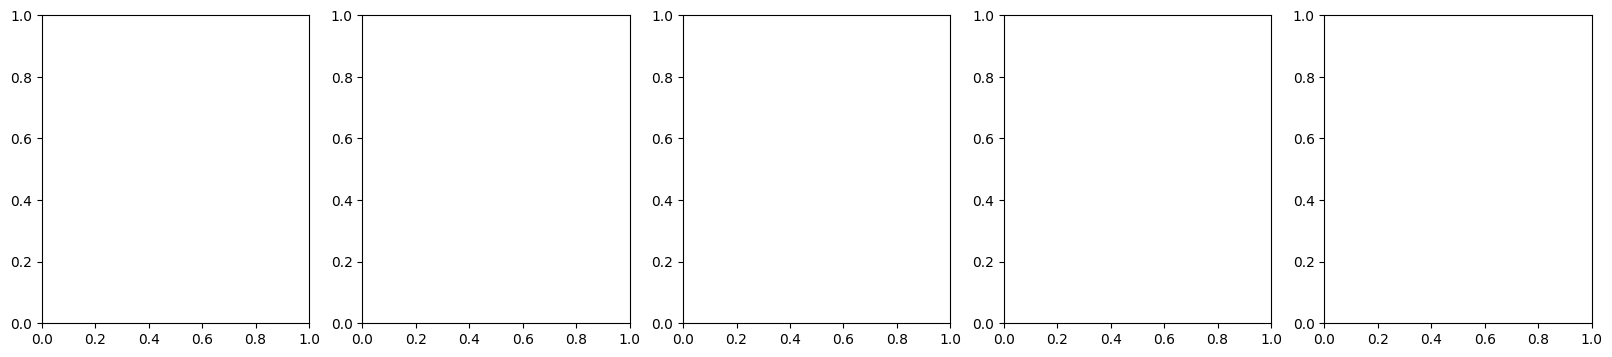

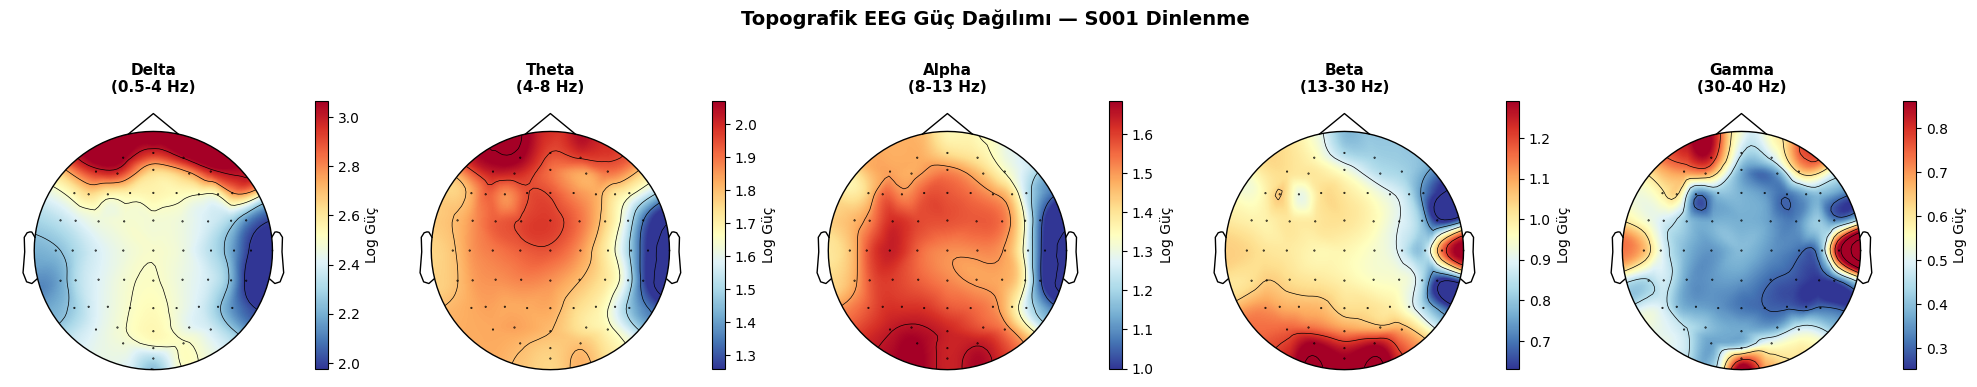

✅ Topografik harita tamamlandı!


In [27]:
%matplotlib inline

# T9 ve T10 hariç tüm kanalları kullan
picks = mne.pick_channels(raw_filtered.ch_names, 
                           exclude=['T9', 'T10'],
                           include=raw_filtered.ch_names)
info_clean = mne.pick_info(raw_filtered.info, picks)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

spectrum = raw_filtered.compute_psd(method='welch', fmin=0.5, fmax=40, n_fft=512)
freqs = spectrum.freqs
psds = spectrum.get_data()

# T9, T10 indekslerini bul ve çıkar
exclude_idx = [raw_filtered.ch_names.index(ch) for ch in ['T9', 'T10'] 
               if ch in raw_filtered.ch_names]
keep_idx = [i for i in range(len(raw_filtered.ch_names)) if i not in exclude_idx]
psds_clean = psds[keep_idx, :]

for idx, (band, (low, high)) in enumerate(bands.items()):
    mask = (freqs >= low) & (freqs <= high)
    band_power = psds_clean[:, mask].mean(axis=1)
    band_power_log = np.log10(band_power * 1e12)

    im, _ = mne.viz.plot_topomap(
        band_power_log,
        info_clean,
        axes=axes[idx],
        show=False,
        cmap='RdYlBu_r',
        vlim=(band_power_log.min(), band_power_log.max()),
        extrapolate='head'
    )
    axes[idx].set_title(f'{band}\n({low}-{high} Hz)', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=axes[idx], shrink=0.8, label='Log Güç')

plt.suptitle('Topografik EEG Güç Dağılımı — S001 Dinlenme', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r"C:\eeg_analysis\outputs\03_topomap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Topografik harita tamamlandı!")